In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statannotations.Annotator import Annotator
import random
import altair as alt
import pybedtools
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
from matplotlib.lines import Line2D

In [2]:
wgddel_path = 'data/deltime_for_muttime_uniquedels.tsv'
ccfdata_path = 'data/muttime_for_deltime_uniquegenes.tsv'
timedel_path = "data/ascat_merged_prepostdel_norm.tsv"
allhitfreq_path = 'data/allhitfreq_wgdstatus.tsv'

In [3]:
wgddel = pd.read_csv(wgddel_path, sep = '\t')
ccfdata = pd.read_csv(ccfdata_path, sep = '\t')
timedel = pd.read_csv(timedel_path, sep='\t')
allhitfreq = pd.read_csv(allhitfreq_path, sep = '\t')

/home/sabari/niveditam/miniconda3/envs/equinox_minimal/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3508: DtypeWarning: Columns (6) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [4]:
def config_rcparams():
    plt.rcParams['font.family'] = ['sans-serif']
    plt.rcParams['font.sans-serif'] = ['arial']
    plt.rcParams['svg.fonttype'] = 'none' 
    plt.rcParams['mathtext.fontset'] = 'custom'
    plt.rcParams['mathtext.cal'] = 'arial'
    plt.rcParams['mathtext.rm'] = 'arial'
    plt.rcParams['axes.linewidth'] = 0.7
    plt.rcParams['xtick.major.width'] = 0.7
    plt.rcParams['ytick.major.width'] = 0.7
    plt.rcParams['xtick.major.size'] = 3
    plt.rcParams['ytick.major.size'] = 3

---

# Fig 4E

Text(0, 0.5, 'CDF')

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial


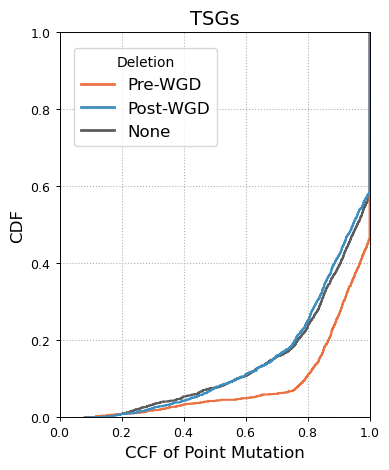

In [5]:
config_rcparams()

# TSGs pancan CCF distributions

data = ccfdata[(ccfdata['role']=='TSG')&(ccfdata['CCF'].isna().values==False)]

plt.figure(figsize=(4,5))

color_map = {
    "postWGD": "#3E8FC1",   
    "preWGD": "#EC7141",    
    "none": "#5C5C5C"         
}

ax = sns.ecdfplot(data=data, x="CCF", hue="wgddeltime_mukh", stat="proportion", palette=color_map)

ax.legend_.set_title("Deletion")
new_labels = ["Post-WGD", "Pre-WGD", "None"]   # put the labels in the same order as they appear
for t, new in zip(ax.legend_.texts, new_labels):
    t.set_text(new)


# Build manual legend handles with lines
legend_handles = [
    Line2D([0], [0], color=color_map["preWGD"], lw=2, label="Pre-WGD"),
    Line2D([0], [0], color=color_map["postWGD"], lw=2, label="Post-WGD"),
    Line2D([0], [0], color=color_map["none"], lw=2, label="None")
]

# Add legend with bbox_to_anchor
ax.legend(
    handles=legend_handles,
    title="Deletion",
    loc="upper left",
    bbox_to_anchor=(0.02, 0.98),
    frameon=True, fontsize=12
)

plt.title('TSGs', fontsize=14)
plt.grid(True, linestyle=':')
plt.xlim(0,1)
plt.ylim(0,1)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.xlabel('CCF of Point Mutation',fontsize=12)
plt.ylabel('CDF',fontsize=12)

SignificanceResult(statistic=1.4284008097165992, pvalue=3.907405183841127e-05)
SignificanceResult(statistic=1.4786823403209226, pvalue=6.442305887452271e-07)
SignificanceResult(statistic=1.0352012756239612, pvalue=0.6921230834931278)


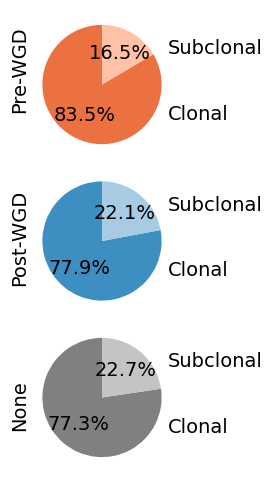

In [6]:
config_rcparams()

# TSGs pancan clonality

data = ccfdata[(ccfdata['role']=='TSG')&(ccfdata['CCF'].isna().values==False)]

# Prepare counts
counts = (
    data.groupby(["wgddeltime_mukh", "clonality"])
    .size()
    .unstack(fill_value=0)
)

order = ["preWGD", "postWGD", "none"]
counts = counts.reindex(order)

color_map = {
    ("preWGD", "clonal"): "#EC7141",     # red
    ("preWGD", "subclonal"): "#FFC2A6",  # light red
    ("postWGD", "clonal"): "#3E8FC1",    # blue
    ("postWGD", "subclonal"): "#A6CBE2", # light blue
    ("none", "clonal"): "#808080",          # gray
    ("none", "subclonal"): "#C4C4C4",       # light gray
}

# Plot
fig, axes = plt.subplots(3, 1, figsize=(4, 6))

for i, wgd in enumerate(order):
    values = counts.loc[wgd]

    # Pick colors for this row
    slice_colors = [
        color_map[(wgd, "clonal")],
        color_map[(wgd, "subclonal")]
    ]

    # Draw pie without labels
    wedges, texts, autotexts = axes[i].pie(
        values,
        labels=None,
        autopct="%1.1f%%",
        startangle=90,
        colors=slice_colors,
        textprops={'fontsize': 14}
    )

    x_pos = 1.3  
    axes[i].text(x_pos-0.2, -0.5, "Clonal", fontsize=14, va="center")
    axes[i].text(x_pos-0.2, 0.6, "Subclonal", fontsize=14, va="center")

titles = {"preWGD": "Pre-WGD", "postWGD": "Post-WGD", "none": "None"}
for i, wgd in enumerate(order):
    fig.text(0.32, 0.78 - i*0.28, titles[wgd], fontsize=14, rotation=90, va="center")

# Run Fisher tests
print(fisher_exact(counts.drop('none'), alternative="two-sided"))   # pre vs post
print(fisher_exact(counts.drop('postWGD'), alternative="two-sided"))  # pre vs none
print(fisher_exact(counts.drop('preWGD'), alternative="two-sided"))   # post vs none

plt.subplots_adjust(hspace=0.05, left=0.2)
plt.show()

---

# Fig 4F

clonality        clonal  subclonal
wgddeltime_mukh                   
preWGD             1641        325
postWGD            1216        344
none               1721        504


Text(0, 0.5, 'CDF')

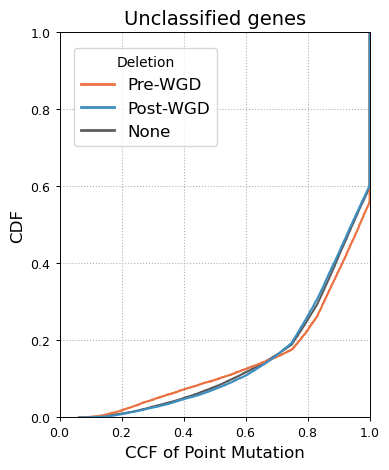

In [7]:
config_rcparams()

# Other genes pancan CCF distributions

data = ccfdata[(ccfdata['role']=='Other')&(ccfdata['CCF'].isna().values==False)]

plt.figure(figsize=(4,5))

color_map = {
    "postWGD": "#3E8FC1",   
    "preWGD": "#EC7141",    
    "none": "#5C5C5C"         
}

ax = sns.ecdfplot(data=data, x="CCF", hue="wgddeltime_mukh", stat="proportion", palette=color_map)


# Build manual legend handles with lines
legend_handles = [
    Line2D([0], [0], color=color_map["preWGD"], lw=2, label="Pre-WGD"),
    Line2D([0], [0], color=color_map["postWGD"], lw=2, label="Post-WGD"),
    Line2D([0], [0], color=color_map["none"], lw=2, label="None")
]

# Add legend with bbox_to_anchor
ax.legend(
    handles=legend_handles,
    title="Deletion",
    loc="upper left",
    bbox_to_anchor=(0.02, 0.98),
    frameon=True, fontsize=12
)

print(counts)

plt.title('Unclassified genes', fontsize=14)
plt.grid(True, linestyle=':')
plt.xlim(0,1)
plt.ylim(0,1)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.xlabel('CCF of Point Mutation',fontsize=12)
plt.ylabel('CDF',fontsize=12)

SignificanceResult(statistic=0.9076260893805854, pvalue=1.00748273617681e-07)
SignificanceResult(statistic=0.9068245729075681, pvalue=2.2783465605133727e-08)
SignificanceResult(statistic=0.9991169089535931, pvalue=0.9446139089530141)


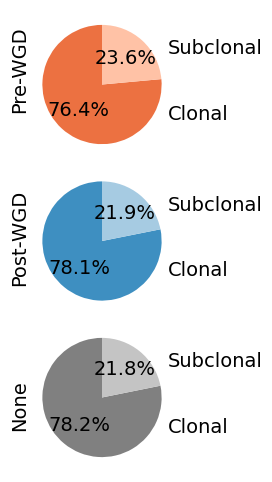

In [8]:
config_rcparams()

# Unclassified genes pancan clonality

# Prepare counts

data = ccfdata[(ccfdata['role']=='Other')&(ccfdata['CCF'].isna().values==False)]

counts = (
    data.groupby(["wgddeltime_mukh", "clonality"])
    .size()
    .unstack(fill_value=0)
)

order = ["preWGD", "postWGD", "none"]
counts = counts.reindex(order)

color_map = {
    ("preWGD", "clonal"): "#EC7141",     # red
    ("preWGD", "subclonal"): "#FFC2A6",  # light red
    ("postWGD", "clonal"): "#3E8FC1",    # blue
    ("postWGD", "subclonal"): "#A6CBE2", # light blue
    ("none", "clonal"): "#808080",          # gray
    ("none", "subclonal"): "#C4C4C4",       # light gray
}

# Plot
fig, axes = plt.subplots(3, 1, figsize=(4, 6))

for i, wgd in enumerate(order):
    values = counts.loc[wgd]

    # Pick colors for this row
    slice_colors = [
        color_map[(wgd, "clonal")],
        color_map[(wgd, "subclonal")]
    ]

    # Draw pie without labels
    wedges, texts, autotexts = axes[i].pie(
        values,
        labels=None,
        autopct="%1.1f%%",
        startangle=90,
        colors=slice_colors,
        textprops={'fontsize': 14}
    )

    # Add custom labels beside pie
    x_pos = 1.3  # shift to right of pie
    axes[i].text(x_pos-0.2, -0.5, "Clonal", fontsize=14, va="center")
    axes[i].text(x_pos-0.2, 0.6, "Subclonal", fontsize=14, va="center")

# Add vertical titles on the left
titles = {"preWGD": "Pre-WGD", "postWGD": "Post-WGD", "none": "None"}
for i, wgd in enumerate(order):
    fig.text(0.32, 0.78 - i*0.28, titles[wgd], fontsize=14, rotation=90, va="center")

# Run Fisher tests
print(fisher_exact(counts.drop('none'), alternative="two-sided"))   # pre vs post
print(fisher_exact(counts.drop('postWGD'), alternative="two-sided"))  # pre vs none
print(fisher_exact(counts.drop('preWGD'), alternative="two-sided"))   # post vs none

plt.subplots_adjust(hspace=0.05, left=0.2)
plt.show()

---

# Fig 4G

In [9]:
# preparinf dataset

# TSGs pancan
tmp1 = wgddel[wgddel.clonality=='none'].copy()
tmp2 = wgddel[wgddel.clonality!='none'].copy()

print('#TSG No mut dels: ',len(tmp1[tmp1.role=='TSG']))
print('#TSG Mut dels: ',len(tmp2[tmp2.role=='TSG']))
print('#Other No mut dels: ',len(tmp1[tmp1.role=='Other']))
print('#Other Mut dels: ',len(tmp2[tmp2.role=='Other']))

tmp1 = tmp1.groupby(['role','wgddeltime_mukh']).del_start.count().to_frame().reset_index().rename(columns={'del_start':'counts'})
tmp1['clonality'] = 'None'

tmp2 = tmp2.groupby(['role','clonality','wgddeltime_mukh']).del_start.count().to_frame().reset_index().rename(columns={'del_start':'counts'})

tmp = pd.concat([tmp1,tmp2]).pivot(index=['role','clonality'],columns='wgddeltime_mukh',values='counts').reset_index().fillna(0)
tmp['preWGD%'] = 100*tmp['preWGD']/(tmp['preWGD']+tmp['postWGD'])
tmp['postWGD%'] = 100*tmp['postWGD']/(tmp['preWGD']+tmp['postWGD'])
tmpa = tmp.copy()
tmp = tmp[['role','clonality','preWGD%','postWGD%']]

if (len(tmp1)<2 | len(tmp2)<4):
    print('Count in all groups is not non-zero')

df1 = tmp[['clonality','role','preWGD%']]
df1.columns = ['Point Mutation','Role','Percentage']
df1['Deletion'] = 'preWGD'

df2 = tmp[['clonality','role','postWGD%']]
df2.columns = ['Point Mutation','Role','Percentage']
df2['Deletion'] = 'postWGD'

df = pd.concat([df1,df2])
df['Point Mutation'] = df['Point Mutation'].replace({'None':' None'})

df['Point Mutation'] = df['Point Mutation'].replace({'clonal':'Clonal','subclonal':'Subclonal'})
df['Deletion'] = df['Deletion'].replace({'preWGD':'Pre-WGD','postWGD':'Post-WGD'})

#TSG No mut dels:  52940
#TSG Mut dels:  3371
#Other No mut dels:  176956
#Other Mut dels:  29719


In [10]:
tmp = df.copy()
order = ["None", "Subclonal", "Clonal"]
tmp["Point Mutation"] = tmp["Point Mutation"].str.strip()
tmp["Point Mutation"] = pd.Categorical(tmp["Point Mutation"], categories=order, ordered=True)

# Map Role names
tmp["Role_label"] = tmp["Role"].replace({"TSG": "TSGs", "Other": "Unclassified genes"})

chart = (
    alt.Chart(tmp)
    .mark_bar()
    .encode(
        x=alt.X(
            "Point Mutation:N",
            sort=order,
            title=None,
            axis=alt.Axis(
                ticks=True, 
                labelFontSize=12.5, 
                titleFontSize=14, 
                titleFontWeight="normal"
            ),
        ),
        y=alt.Y(
            "Percentage:Q",
            axis=alt.Axis(
                grid=False,
                title="% of Deletions",
                titleFontSize=14,
                titleFontWeight="normal",
                titlePadding=6,
                labelExpr="datum.value",
                labelFontSize=12.5
            ),
        ),
        column=alt.Column(
            "Role_label:N",
            sort=["TSGs", "Unclassified genes"],
            title=None,
            header=alt.Header(
                labelOrient="bottom",
                labelFontSize=14,
                labelFontWeight="normal"
            ),
        ),
        color=alt.Color(
            "Deletion:N",
            scale=alt.Scale(range=["#91bfdb", "#ef8a62"]),
            legend=alt.Legend(
                title="Deletion",
                labelFontSize=12.5,
                titleFontSize=13,
                titleFontWeight="normal",
                labelPadding=40
            ),
        ),
    )
    .properties(width=70, height=270)
    .configure_view(strokeOpacity=0)
)

chart


alt.Chart(...)

---

# Fig S8C

In [11]:
# preparing dataset

tmp1 = wgddel[(wgddel.clonality=='none')&(wgddel.role=='TSG')].copy()
tmp2 = wgddel[(wgddel.clonality!='none')&(wgddel.role=='TSG')].copy()

tmp1 = tmp1.groupby(['CODE','wgddeltime_mukh']).del_start.count().to_frame().reset_index().rename(columns={'del_start':'counts'})
tmp1['mut'] = 'noMut'
tmp1 = tmp1.rename(columns={'CODE':'CODE'})

tmp2 = tmp2.groupby(['CODE','wgddeltime_mukh']).del_start.count().to_frame().reset_index().rename(columns={'del_start':'counts'})
tmp2['mut'] = 'Mut'

tot = tmp2.pivot(index='CODE',columns=['wgddeltime_mukh'],values='counts').fillna(0)
tot['tot'] = tot['postWGD'] + tot['preWGD']

tmp = pd.concat([tmp1,tmp2]).pivot(index=['CODE','mut'],columns='wgddeltime_mukh',values='counts').reset_index().fillna(0)
mutprepost = tmp.copy()

In [12]:
# Fisher's exact test

results = []

# Group by tumor type
for code, df_sub in mutprepost.groupby("CODE"):
    # Expecting df_sub to have 2 rows: one for "Mut", one for "noMut"
    if set(df_sub["mut"]) != {"Mut", "noMut"}:
        continue  # skip tumor types without both categories
    
    # Build contingency table
    mut_row = df_sub[df_sub["mut"] == "Mut"][["postWGD", "preWGD"]].values[0]
    nomut_row = df_sub[df_sub["mut"] == "noMut"][["postWGD", "preWGD"]].values[0]
    
    table = [
        [mut_row[0], mut_row[1]],     # Mut: postWGD, preWGD
        [nomut_row[0], nomut_row[1]]  # noMut: postWGD, preWGD
    ]
    
    # Fisher's exact test (two-sided)
    oddsratio, pval = fisher_exact(table, alternative="two-sided")
    
    results.append({
        "CODE": code,
        "oddsratio": oddsratio,
        "pval": pval
    })

# Convert to dataframe
res_df = pd.DataFrame(results)

# Apply FDR correction
res_df["fdr"] = multipletests(res_df["pval"], method="fdr_bh")[1]

codes = tot[tot['tot']>=10].index.values

sig = res_df[res_df.fdr<=0.05]
print(len(np.intersect1d(sig.CODE.unique(),codes))==len(sig))

sig

True


,CODE,oddsratio,pval,fdr
2,BRCA,0.501280,1.270968e-07,7.880002e-07
5,COAD,0.392522,1.865377e-09,1.445667e-08
7,ESCA,0.379930,3.441786e-07,1.778256e-06
8,GBM,0.183594,2.856749e-04,8.855923e-04
9,HNSC,0.597040,1.296753e-04,4.466595e-04
11,KIRC,0.119708,5.295166e-10,5.471672e-09
13,LGG,0.071543,2.528185e-16,3.918687e-15
14,LIHC,0.537212,2.768093e-03,5.720725e-03
15,LUAD,0.700984,3.252264e-03,6.301261e-03
16,LUSC,0.734210,2.631762e-03,5.720725e-03


In [13]:
# preparing dataset

mutprepost_sig = mutprepost[mutprepost.CODE.isin(sig.CODE.unique())]
mutprepost_sig['preWGD%'] = 100*mutprepost_sig['preWGD']/(mutprepost_sig['preWGD']+mutprepost_sig['postWGD'])
mutprepost_sig['postWGD%'] = 100*mutprepost_sig['postWGD']/(mutprepost_sig['preWGD']+mutprepost_sig['postWGD'])
mutprepost_sig = mutprepost_sig[['CODE','mut','preWGD%','postWGD%']]

/tmp/ipykernel_9987/3353234405.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mutprepost_sig['preWGD%'] = 100*mutprepost_sig['preWGD']/(mutprepost_sig['preWGD']+mutprepost_sig['postWGD'])
/tmp/ipykernel_9987/3353234405.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mutprepost_sig['postWGD%'] = 100*mutprepost_sig['postWGD']/(mutprepost_sig['preWGD']+mutprepost_sig['postWGD'])


In [14]:
# preparing dataset

tmp = ccfdata[(ccfdata['role']=='TSG')&(ccfdata['wgddeltime_mukh']!='none')&(ccfdata['CCF'].isna().values==False)]
tmp = tmp.groupby(['CODE','wgddeltime_mukh']).clonality.value_counts().to_frame().rename(columns={'clonality':'counts'}).reset_index()
delclosub = tmp.pivot(index=['CODE','wgddeltime_mukh'], columns='clonality', values='counts').fillna(0).reset_index()

In [15]:
# preparing dataset

delclosub_sig = delclosub
delclosub_sig['clonal%'] = 100*delclosub_sig['clonal']/(delclosub_sig['clonal']+delclosub_sig['subclonal'])
delclosub_sig['subclonal%'] = 100*delclosub_sig['subclonal']/(delclosub_sig['clonal']+delclosub_sig['subclonal'])
delclosub_sig = delclosub_sig[['CODE','wgddeltime_mukh','clonal%','subclonal%']]

In [16]:
df = delclosub_sig.copy()
df = df[df.CODE.isin(mutprepost_sig.CODE.unique())]
pivot = df.pivot(index="CODE", columns="wgddeltime_mukh", values="clonal%").dropna()
pivot["diff"] = (pivot["preWGD"] - pivot["postWGD"])
pivot = pivot.merge(sig[["CODE", "fdr"]], on='CODE', how='left')
pivot = pivot.sort_values("preWGD", ascending=True)
order = pivot["CODE"].tolist()
orderttype = order.copy()

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial


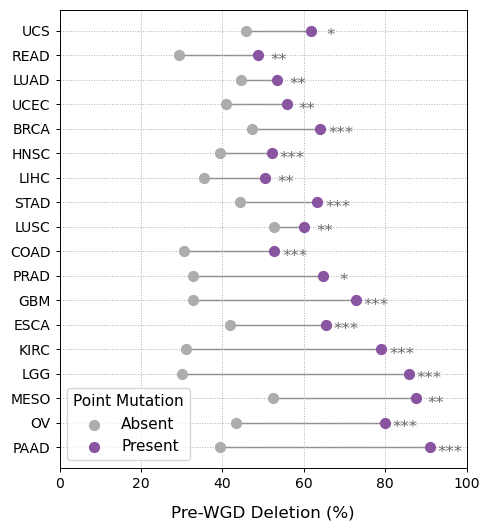

In [17]:
config_rcparams()

df = mutprepost_sig.copy()
pivot = df.pivot(index="CODE", columns="mut", values="preWGD%")
pivot["diff"] = (pivot["Mut"] - pivot["noMut"]).abs()
pivot = pivot.merge(sig[["CODE", "fdr"]], left_index=True, right_on="CODE")
#orderttype = ['UCS','READ','LUAD','UCEC','BRCA','HNSC','LIHC','STAD','LUSC','COAD','PRAD','GBM','ESCA','KIRC','LGG','MESO','OV','PAAD']
order=orderttype 

def fdr_to_stars(fdr):
    if fdr < 0.001:
        return "***"
    elif fdr < 0.01:
        return "**"
    elif fdr < 0.05:
        return "*"
    else:
        return ""

# Plot
plt.figure(figsize=(5, len(order)*0.3))

for i, row in pivot.iterrows():
    code = row["CODE"]
    y = order.index(code)
    x_mut = row["Mut"]
    x_nomut = row["noMut"]
    
    # Connecting line
    plt.plot([x_nomut, x_mut], [y, y], color="grey", lw=1, zorder=1)
    
    # Points
    plt.scatter(x_nomut, y, color="#ADADAD", s=50, label="Absent" if y==0 else "", zorder=2)
    plt.scatter(x_mut, y, color="#8955A1", s=50, label="Present" if y==0 else "", zorder=2)
    
    # Significance annotation
    stars = fdr_to_stars(row["fdr"])
    if stars:
        x_center = (x_mut + x_nomut) / 2
        x_range = abs(x_mut - x_nomut)
        x_right = max(x_mut, x_nomut) 
        plt.text(x_right+5, y-0.5 , stars, ha="center", va="bottom",
                 fontsize=12, color='dimgray')

# Formatting
plt.yticks(range(len(order)), order)
plt.xlabel("Pre-WGD Deletion (%)", fontsize=12, labelpad=10)

# Dotted grid
plt.grid(True, linestyle=":", linewidth=0.7)

# Legend tweaks
plt.legend(title='Point Mutation', frameon=True, loc='lower left',fontsize=11, title_fontsize=11)
plt.xlim(0,100)
plt.tight_layout()

plt.show()

---

# Fig S8B

In [18]:
# Fisher's exact test

results = []

# Group by tumor type
for code, df_sub in delclosub.groupby("CODE"):
    if set(df_sub["wgddeltime_mukh"]) != {"preWGD", "postWGD"}:
        continue  
    
    # Build contingency table
    preWGD_row = df_sub[df_sub["wgddeltime_mukh"] == "preWGD"][["clonal","subclonal"]].values[0]
    postWGD_row = df_sub[df_sub["wgddeltime_mukh"] == "postWGD"][["clonal","subclonal"]].values[0]
    
    table = [
        [preWGD_row[0], preWGD_row[1]],     # preWGD: clonal, subclonal
        [postWGD_row[0], postWGD_row[1]]  # postWGD: clonal, subclonal
    ]
    
    # Fisher's exact test (two-sided)
    oddsratio, pval = fisher_exact(table, alternative="two-sided")
    
    results.append({
        "CODE": code,
        "oddsratio": oddsratio,
        "pval": pval
    })

# Convert to dataframe
res_df = pd.DataFrame(results)

# Apply FDR correction
res_df["fdr"] = multipletests(res_df["pval"], method="fdr_bh")[1]

codes = tot[tot['tot']>=10].index.values

sig = res_df[res_df.fdr<=0.05]
print(len(np.intersect1d(sig.CODE.unique(),codes))==len(sig))

True


<Figure size 324x850 with 0 Axes>

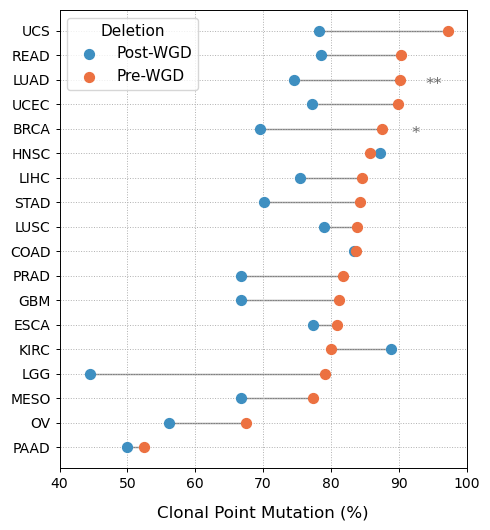

In [19]:
config_rcparams()

# Plot

plt.figure(figsize=(len(order)*0.18, 8.5)) 

df = delclosub_sig.copy()
df = df[df.CODE.isin(mutprepost_sig.CODE.unique())] # showing only the tumor types sig in the mutprepost_sig tumor type plot

# Pivot for easier manipulation
pivot = df.pivot(index="CODE", columns="wgddeltime_mukh", values="clonal%").dropna()

# Compute difference Mut - noMut
pivot["diff"] = (pivot["preWGD"] - pivot["postWGD"])#.abs()

# Merge with significance values
pivot = pivot.merge(sig[["CODE", "fdr"]], on='CODE', how='left')# left_index=True, right_on="CODE")

# Order tumor types by difference
pivot = pivot.sort_values("preWGD", ascending=True)

# Order tumor types same as previous plot
order = orderttype

# Function to convert FDR → stars
def fdr_to_stars(fdr):
    if fdr < 0.001:
        return "***"
    elif fdr < 0.01:
        return "**"
    elif fdr < 0.05:
        return "*"
    else:
        return ""

# Plot
plt.figure(figsize=(5, len(order)*0.3))

for i, row in pivot.iterrows():
    code = row["CODE"]
    y = order.index(code)
    x_pre = row["preWGD"]
    x_post = row["postWGD"]
    
    # Connecting line
    plt.plot([x_post, x_pre], [y, y], color="grey", lw=1, zorder=1)
    
    # Points
    plt.scatter(x_post, y, color="#3E8FC1", s=50, label="Post-WGD" if y==0 else "", zorder=2)
    plt.scatter(x_pre, y, color="#EC7141", s=50, label="Pre-WGD" if y==0 else "", zorder=2)
    
    # Significance annotation from Fishers test
    stars = fdr_to_stars(row["fdr"])
    if stars:
        x_center = (x_pre + x_post) / 2
        x_range = abs(x_pre - x_post)
        x_right = max(x_pre, x_post) 
        plt.text(x_right+5, y-0.5 , stars, ha="center", va="bottom",
                 fontsize=12, color='dimgray')
# Formatting
plt.yticks(range(len(order)), order)
plt.xlabel("Clonal Point Mutation (%)", fontsize=12, labelpad=10)

# Dotted grid
plt.grid(True, linestyle=":", linewidth=0.7)

# Legend tweaks
plt.legend(title='Deletion', frameon=True,fontsize=11, title_fontsize=11)
plt.xlim(40,100)
plt.tight_layout()

plt.show()

---

# Fig S8D

In [20]:
# preparing dataset

tmp2 = wgddel[(wgddel.clonality!='none')&(wgddel.role=='TSG')].copy()

tmp2 = tmp2.groupby(['CODE','clonality','wgddeltime_mukh']).del_start.count().to_frame().reset_index().rename(columns={'del_start':'counts'})
cloprepost = tmp2.pivot(index=['CODE','clonality'],columns='wgddeltime_mukh',values='counts').reset_index().fillna(0)

In [21]:
# Fisher's exact test

results = []

# Group by tumor type
for code, df_sub in cloprepost.groupby("CODE"):
    # Expecting df_sub to have 2 rows: one for "Mut", one for "noMut"
    if set(df_sub["clonality"]) != {"clonal", "subclonal"}:
        continue  # skip tumor types without both categories
    
    # Build contingency table
    mut_row = df_sub[df_sub["clonality"] == "clonal"][["postWGD", "preWGD"]].values[0]
    nomut_row = df_sub[df_sub["clonality"] == "subclonal"][["postWGD", "preWGD"]].values[0]
    
    table = [
        [mut_row[0], mut_row[1]],     # Mut: postWGD, preWGD
        [nomut_row[0], nomut_row[1]]  # noMut: postWGD, preWGD
    ]
    
    # Fisher's exact test (two-sided)
    oddsratio, pval = fisher_exact(table, alternative="two-sided")
    
    results.append({
        "CODE": code,
        "oddsratio": oddsratio,
        "pval": pval
    })

# Convert to dataframe
res_df = pd.DataFrame(results)

# Apply FDR correction
res_df["fdr"] = multipletests(res_df["pval"], method="fdr_bh")[1]

codes = tot[tot['tot']>=10].index.values

sig = res_df[res_df.fdr<=0.05]
print(len(np.intersect1d(sig.CODE.unique(),codes))==len(sig))

sig

True


,CODE,oddsratio,pval,fdr
2,BRCA,0.316901,0.000696,0.010093
14,LUAD,0.298423,0.000192,0.005573


In [22]:
# preparing dataset 

cloprepost_sig = cloprepost#[cloprepost.CODE.isin(sig.CODE.unique())]
cloprepost_sig['preWGD%'] = 100*cloprepost_sig['preWGD']/(cloprepost_sig['preWGD']+cloprepost_sig['postWGD'])
cloprepost_sig['postWGD%'] = 100*cloprepost_sig['postWGD']/(cloprepost_sig['preWGD']+cloprepost_sig['postWGD'])
cloprepost_sig = cloprepost_sig[['CODE','clonality','preWGD%','postWGD%']]

x = cloprepost_sig.CODE.value_counts()
cloprepost_sig = cloprepost_sig[cloprepost_sig.CODE.isin(x[x==2].index.values)]

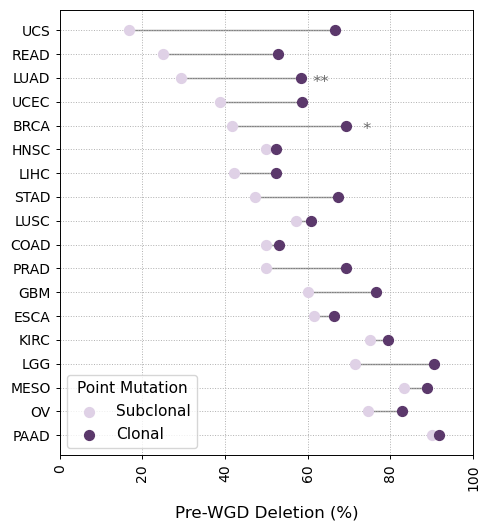

In [23]:
config_rcparams()

df = cloprepost_sig.copy()
df = df[df.CODE.isin(mutprepost_sig.CODE.unique())] 
pivot = df.pivot(index="CODE", columns="clonality", values="preWGD%")

pivot["diff"] = (pivot["clonal"] - pivot["subclonal"])
pivot = pivot.merge(sig[["CODE", "fdr"]],on="CODE", how='left')
order = orderttype 

def fdr_to_stars(fdr):
    if fdr < 0.001:
        return "***"
    elif fdr < 0.01:
        return "**"
    elif fdr < 0.05:
        return "*"
    else:
        return ""

# Plot
plt.figure(figsize=(5, len(order)*0.3))

for i, row in pivot.iterrows():
    code = row["CODE"]
    y = order.index(code)
    x_mut = row["clonal"]
    x_nomut = row["subclonal"]
    
    plt.plot([x_nomut, x_mut], [y, y], color="grey", lw=1, zorder=1)

    plt.scatter(x_nomut, y, color="#DFD1E6", s=50, label="Subclonal" if y==0 else "", zorder=2)
    plt.scatter(x_mut, y, color="#5B386B", s=50, label="Clonal" if y==0 else "", zorder=2)

    stars = fdr_to_stars(row["fdr"])
    if stars:
        x_center = (x_mut + x_nomut) / 2
        x_range = abs(x_mut - x_nomut)
        x_right = max(x_mut, x_nomut) 
        plt.text(x_right+5, y-0.5 , stars, ha="center", va="bottom",
                 fontsize=12, color='dimgray')

plt.yticks(range(len(order)), order)
plt.xticks(rotation=90)

plt.grid(True, linestyle=":", linewidth=0.7)

plt.xlabel("Pre-WGD Deletion (%)", fontsize=12, labelpad=10)

plt.legend(title='Point Mutation', frameon=True, loc='lower left',fontsize=11, title_fontsize=11)
plt.xlim(0,100)
plt.tight_layout()

plt.show()

---

# Fig S8A

In [24]:
# preparing dataset

tmp1 = ccfdata[(ccfdata['role']=='TSG')&(ccfdata['CCF'].isna().values==True)&(ccfdata['wgddeltime_mukh']!='none')]
tmp2 = ccfdata[(ccfdata['role']=='TSG')&(ccfdata['CCF'].isna().values==False)&(ccfdata['wgddeltime_mukh']!='none')]
tmp1 = tmp1.groupby(['Hugo_Symbol']).wgddeltime_mukh.value_counts().to_frame().rename(columns={'wgddeltime_mukh':'counts'}).reset_index()
tmp1['mut'] = 'noMut'
tmp2 = tmp2.groupby(['Hugo_Symbol']).wgddeltime_mukh.value_counts().to_frame().rename(columns={'wgddeltime_mukh':'counts'}).reset_index()
tmp2['mut'] = 'Mut'
tot = tmp2.pivot(index='Hugo_Symbol',columns=['wgddeltime_mukh'],values='counts').fillna(0)
tot['tot'] = tot['postWGD'] + tot['preWGD']
tmp = pd.concat([tmp1,tmp2]).pivot(index=['Hugo_Symbol','mut'],columns='wgddeltime_mukh',values='counts').reset_index().fillna(0)
mutprepost_gene = tmp.copy()

In [25]:
# Fisher's exact test

results = []

# Group by tumor type
for Hugo_Symbol, df_sub in mutprepost_gene.groupby("Hugo_Symbol"):
    # Expecting df_sub to have 2 rows: one for "Mut", one for "noMut"
    if set(df_sub["mut"]) != {"Mut", "noMut"}:
        continue  # skip tumor types without both categories
    
    # Build contingency table
    mut_row = df_sub[df_sub["mut"] == "Mut"][["postWGD", "preWGD"]].values[0]
    nomut_row = df_sub[df_sub["mut"] == "noMut"][["postWGD", "preWGD"]].values[0]
    
    table = [
        [mut_row[0], mut_row[1]],     # Mut: postWGD, preWGD
        [nomut_row[0], nomut_row[1]]  # noMut: postWGD, preWGD
    ]
    
    # Fisher's exact test (two-sided)
    oddsratio, pval = fisher_exact(table, alternative="two-sided")
    
    results.append({
        "Hugo_Symbol": Hugo_Symbol,
        "oddsratio": oddsratio,
        "pval": pval
    })

# Convert to dataframe
res_df = pd.DataFrame(results)

# Apply FDR correction
res_df["fdr"] = multipletests(res_df["pval"], method="fdr_bh")[1]

Hugo_Symbols = tot[tot['tot']>=10].index.values

sig = res_df[res_df.fdr<=0.05]
print(len(np.intersect1d(sig.Hugo_Symbol.unique(),Hugo_Symbols))==len(sig))

sig

False


,Hugo_Symbol,oddsratio,pval,fdr
16,BAP1,0.141266,1.279642e-04,2.079418e-03
26,CDH1,0.220814,4.022212e-04,5.809862e-03
30,CDKN2A,0.107444,2.540710e-11,1.100974e-09
73,MEN1,0.062856,2.348254e-03,2.775209e-02
88,PTEN,0.065457,1.515919e-14,9.853476e-13
98,RB1,0.182979,4.872926e-06,1.266961e-04
106,SMAD4,0.056129,4.767232e-05,8.853431e-04
107,SMARCA4,0.330641,1.390727e-03,1.807945e-02
111,STK11,0.026862,7.898481e-10,2.567006e-08
119,TP53,0.119135,3.579244e-51,4.653018e-49


In [26]:
# preparing dataset 

mutprepost_gene_sig = mutprepost_gene.copy()#[mutprepost_gene.Hugo_Symbol.isin(sig.Hugo_Symbol.unique())]
mutprepost_gene_sig['preWGD%'] = 100*mutprepost_gene_sig['preWGD']/(mutprepost_gene_sig['preWGD']+mutprepost_gene_sig['postWGD'])
mutprepost_gene_sig['postWGD%'] = 100*mutprepost_gene_sig['postWGD']/(mutprepost_gene_sig['preWGD']+mutprepost_gene_sig['postWGD'])
mutprepost_gene_sig = mutprepost_gene_sig[['Hugo_Symbol','mut','preWGD%','postWGD%']]

df = mutprepost_gene_sig.copy()
pivot = df.pivot(index="Hugo_Symbol", columns="mut", values="preWGD%")
pivot = pivot.merge(sig[["Hugo_Symbol", "fdr"]], on="Hugo_Symbol", how='left')

# Order tumor types by decreasing all-hit freq
order = allhitfreq[(allhitfreq.role=='TSG')&(allhitfreq.WGD=='WGD+')].sort_values(by = 'allhitfreq',ascending=False)[['Hugo_Symbol']].set_index('Hugo_Symbol')
pivot = order.join(pivot.set_index('Hugo_Symbol')).reset_index()

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial


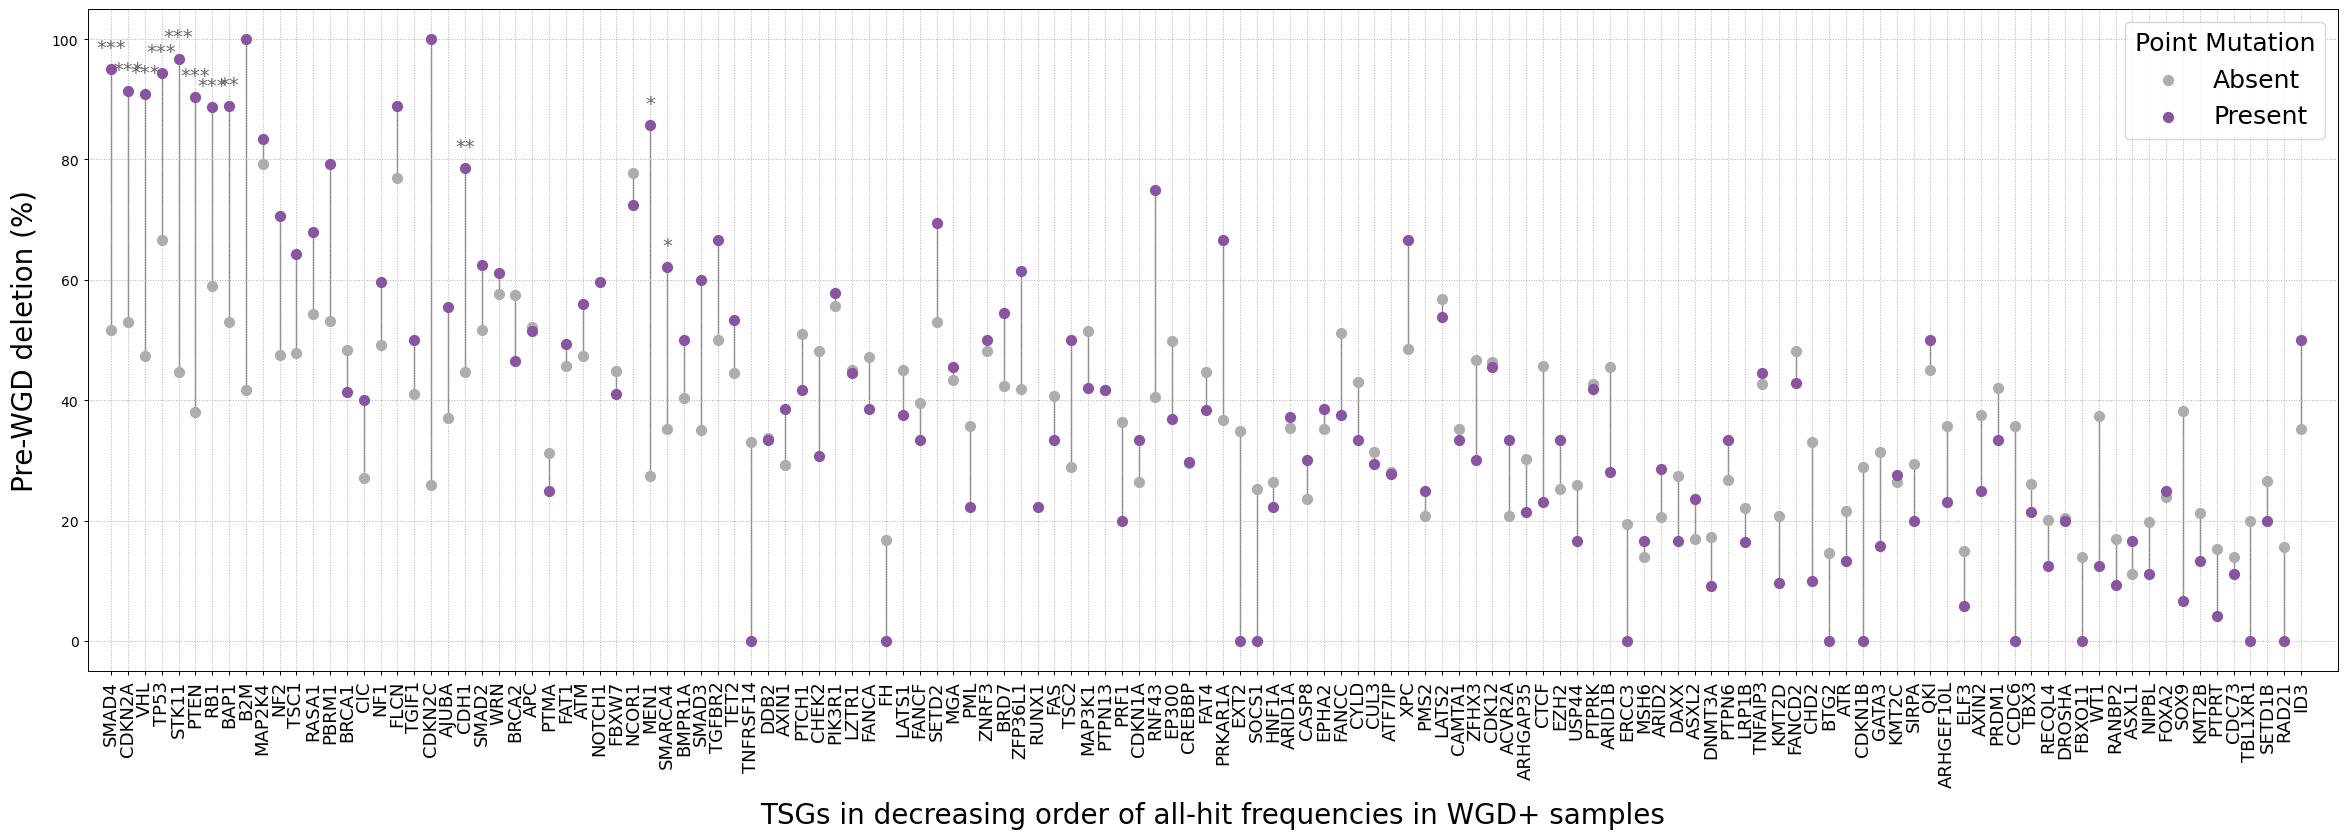

In [27]:
config_rcparams()

plt.figure(figsize=(len(order)*0.18, 8.5)) 

def fdr_to_stars(fdr):
    if fdr < 0.001:
        return "***"
    elif fdr < 0.01:
        return "**"
    elif fdr < 0.05:
        return "*"
    else:
        return ""

for i, row in pivot.iterrows():
    Hugo_Symbol = row["Hugo_Symbol"]
    x = i   # position in the pivot, already sorted by order
    y_mut = row["Mut"]
    y_nomut = row["noMut"]

    plt.plot([x, x], [y_nomut, y_mut], color="grey", lw=1, zorder=1)
    
    plt.scatter(x, y_nomut, color="#ADADAD", s=50, 
                label="Absent" if i==0 else "", zorder=2)
    plt.scatter(x, y_mut, color="#8955A1", s=50, 
                label="Present" if i==0 else "", zorder=2)
    
    stars = fdr_to_stars(row["fdr"])
    if stars:
        y_top = max(y_mut, y_nomut)
        plt.text(x, y_top + 2, stars, ha="center", va="bottom", 
                 fontsize=14, color="dimgray")

plt.xticks(range(len(order)), pivot["Hugo_Symbol"], rotation=90, fontsize=13)
plt.ylabel("Pre-WGD deletion (%)", fontsize=20, labelpad=10)
plt.xlabel("TSGs in decreasing order of all-hit frequencies in WGD+ samples", fontsize=20, labelpad=10)

plt.grid(True, linestyle=":", linewidth=0.7)

plt.legend(title='Point Mutation', frameon=True, fontsize=18, title_fontsize=18)
plt.xlim(-1.4,132.2)
plt.tight_layout()

plt.show()

---

# Fig S8E

In [28]:
# preparing dataset

tmp1 = timedel[['wgddeltime','tissue','chrom','del_start','del_end','del_length_normalised']].copy().rename(columns={'wgddeltime':'wgddeltime_mukh'})
tmp1 = tmp1[~tmp1.chrom.isin(['X','Y'])]
tmp1.chrom = tmp1.chrom.astype('int64')

tmp2 = wgddel[(wgddel['role']=='TSG')&(wgddel['clonality']!='none')]

print(len(tmp2))
muttsggd1_dellen = pd.merge(tmp2,tmp1,on=['wgddeltime_mukh','tissue','chrom','del_start','del_end'],how='left')
print(len(muttsggd1_dellen))

3371
3371


/tmp/ipykernel_9987/3402152919.py:36: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  ax.legend(handles,labels= ["Pre-WGD Deletion", "Post-WGD Deletion"], bbox_to_anchor=(0.85, 1.2), title="",fontsize=10, frameon=False)


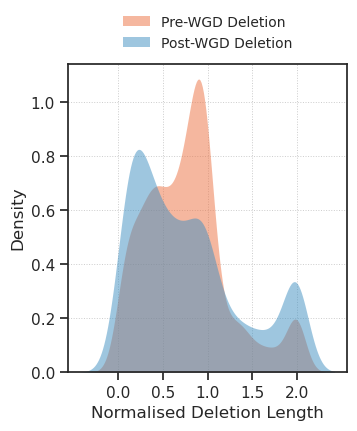

In [29]:
config_rcparams()

sns.set(rc={'figure.figsize':(3.6,4)})
sns.set_style('white')

palette = {'preWGD':'#EC7141','postWGD':'#3E8FC1'}
data = muttsggd1_dellen

uniqdel = ['tissue','chrom','del_start','del_end']
    
data1 = data[data.wgddeltime_mukh=='preWGD'][uniqdel + ['del_length_normalised']].drop_duplicates()
data2 = data[data.wgddeltime_mukh=='postWGD'][uniqdel + ['del_length_normalised']].drop_duplicates()
ax = sns.kdeplot(data1['del_length_normalised'], x = 'del_length_normalised', color='#EC7141', fill=True, linewidth=0, alpha=0.5)
ax = sns.kdeplot(data2['del_length_normalised'], x = 'del_length_normalised', color='#3E8FC1', fill=True, linewidth=0, alpha=0.5)


ax.grid(True, linestyle=":", linewidth=0.7)
ax.set_xticks([0, 0.5, 1, 1.5, 2])
ax.set_xlabel('Normalised Deletion Length',fontsize=12)

for tick in ax.xaxis.get_major_ticks():
    tick.tick1line.set_visible(True)   # bottom
    tick.tick2line.set_visible(False)  # top
    tick.tick1line.set_color('k')
    tick.tick1line.set_linewidth(1.2)
    tick.tick1line.set_zorder(10)

for tick in ax.yaxis.get_major_ticks():
    tick.tick1line.set_visible(True)   # left
    tick.tick2line.set_visible(False)  # right
    tick.tick1line.set_color('k')
    tick.tick1line.set_linewidth(1.2)
    tick.tick1line.set_zorder(10)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles,labels= ["Pre-WGD Deletion", "Post-WGD Deletion"], bbox_to_anchor=(0.85, 1.2), title="",fontsize=10, frameon=False)

plt.show()

---